In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('../..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## LOAD DATASET

In [3]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
import torch.nn as nn
from src.CHM.test import test_cbm_classifier
from src.utils.plot import plot_test_results, plot_concept_error_heatmap, analyze_misclassifications_concepts, plot_concept_uncertainty_heatmap

AllenNLP not available. Registrable won't work.


In [4]:
from src.utils.dataset import load_concept_data, prepare_class_concept_dataset, parse_classes, parse_concepts
import torch
import numpy as np

concepts = parse_concepts('../../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt')
classes = parse_classes('../../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt')
class2id = {c: idx for idx, c in enumerate(classes)}
class_concept_matrix = torch.from_numpy(np.loadtxt('../../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))
dataset, concept2id, id2concept = load_concept_data('../../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json', concepts)
datasetClasses = prepare_class_concept_dataset(class_concept_matrix, class2id)

In [5]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset

features_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)

BATCH_SIZE = 32
EPOCHS = 6
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


## CBM LINEAR CLASSIFIER

### Load Boxes

In [6]:
from src.BOX.model import BoxHierarchyModel, BoxHierarchyModelJoint
import torch
from src.utils.box import get_box_dict, get_geometric_class_weights, prepara_tensore_box

BOX_DIM = 16

box_model = BoxHierarchyModel(num_concepts=len(concepts), dim=BOX_DIM)
box_model.load_state_dict(torch.load("../../AwA2_Dataset_Labels/Animals_with_Attributes2/modello_gerarchia.pth"))
box_dict = get_box_dict(box_model, id2concept)
box_tensors = prepara_tensore_box(box_dict, concept2id)

### CBM with boxes

#### Train

In [7]:
info = "boxes"  
b_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(b_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
b_history = train_cbm_classifier(
        b_model, 
        train_dataloader, 
        val_dataloader, 
        optimizer, 
        criterion, 
        class_concept_matrix, 
        box_tensors, 
        EPOCHS, 
        device
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/6 | TRAIN: Loss=0.160, Acc=98.0% | VAL: Loss=0.007, Acc=100.0%
Epoca   3/6 | TRAIN: Loss=0.004, Acc=100.0% | VAL: Loss=0.002, Acc=100.0%
Epoca   4/6 | TRAIN: Loss=0.002, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   5/6 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   6/6 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   7/6 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Addestramento completato.


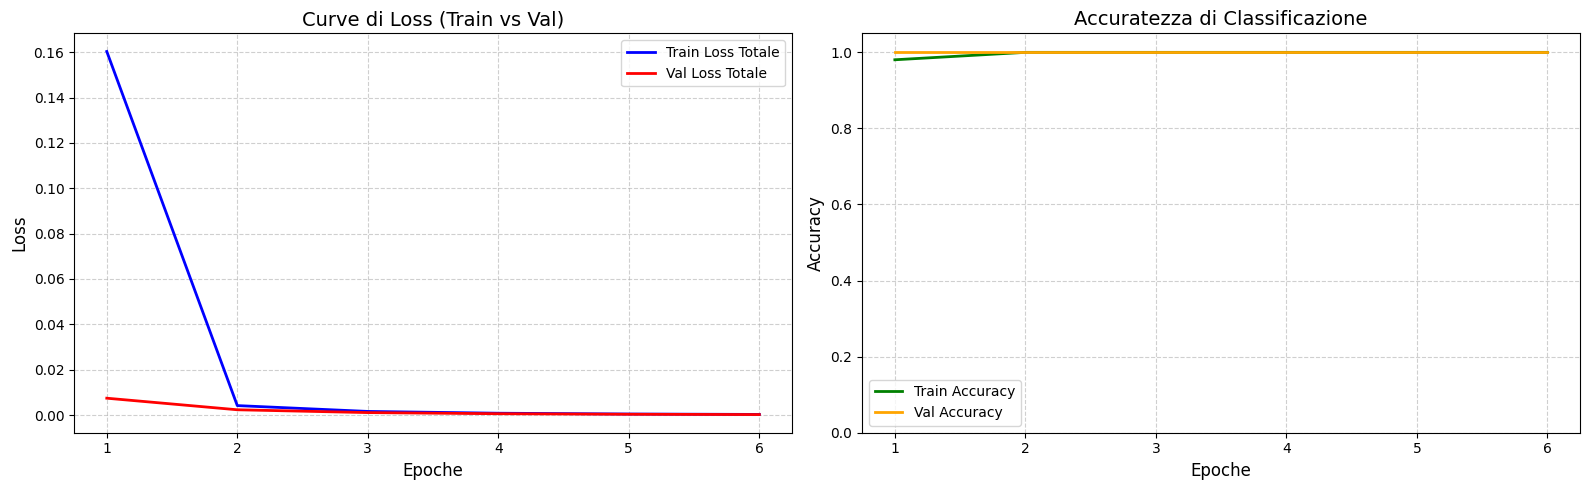

In [8]:
from src.utils.plot import plot_history
plot_history(b_history)

#### Oracle Test

In [9]:
accuracy, preds, labels, _, _, _ = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


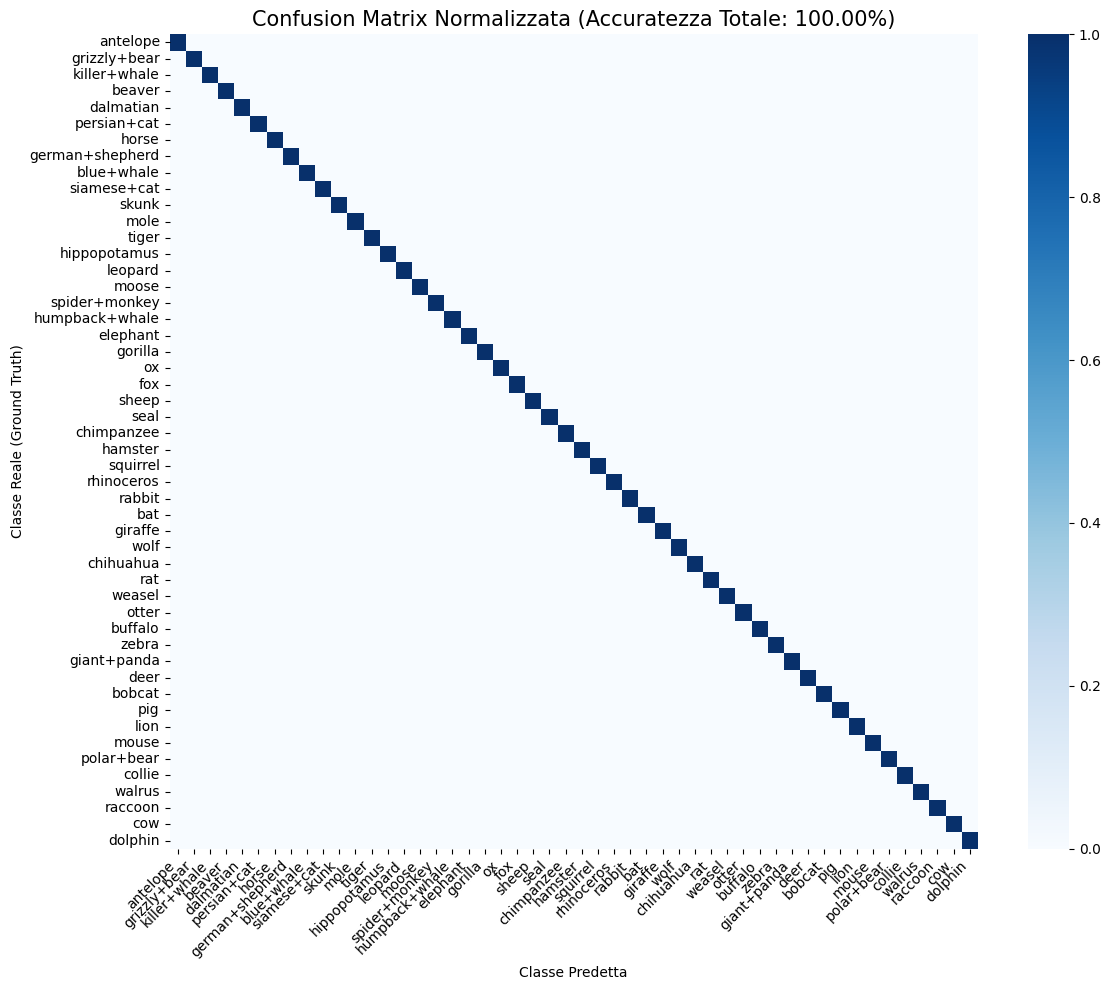


Analisi degli Errori Principali:


In [10]:
plot_test_results(accuracy, preds, labels, class_names=classes)

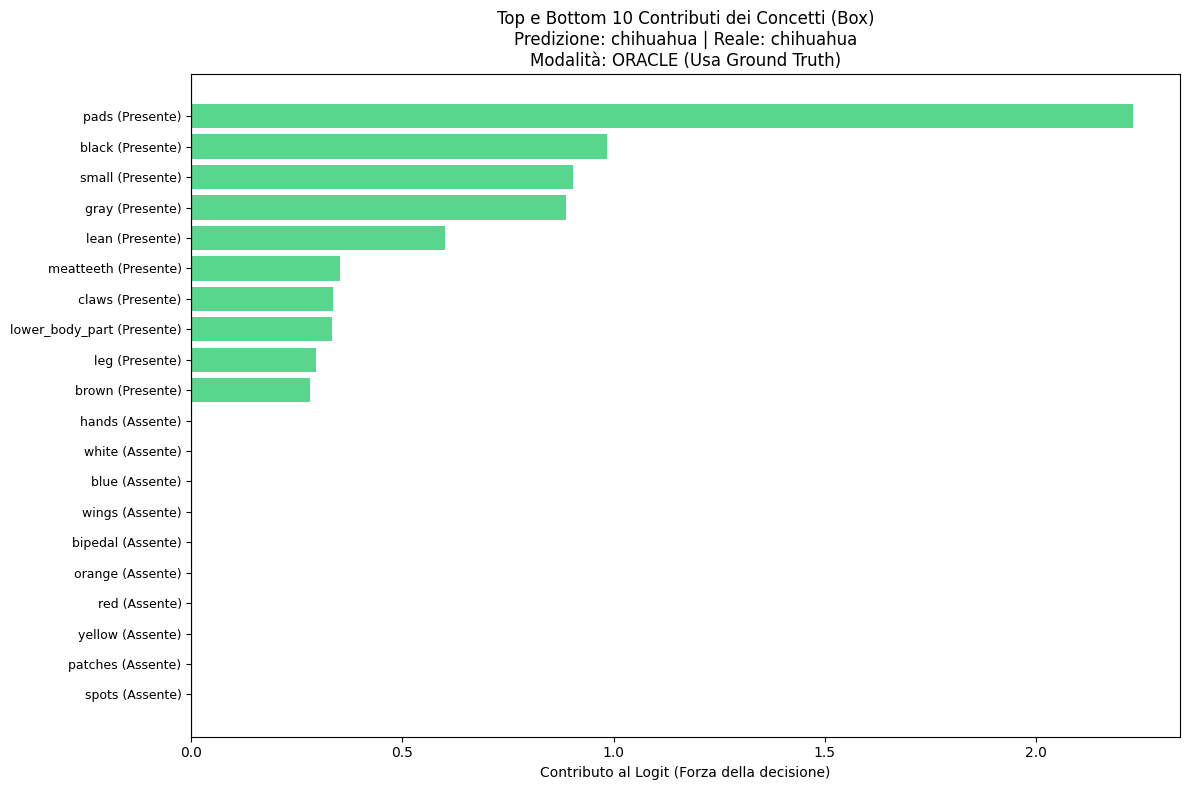

True

In [11]:
from src.CHM.interpretation import explain_prediction

explain_prediction(b_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, target_class="chihuahua")

### CBM with cond prob distrib

#### Train

In [12]:
info = "rel_matrix"
bipolar = True
cp_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(cp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cp_history = train_cbm_classifier(
    cp_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=bipolar
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/6 | TRAIN: Loss=0.149, Acc=98.3% | VAL: Loss=0.007, Acc=100.0%
Epoca   3/6 | TRAIN: Loss=0.004, Acc=100.0% | VAL: Loss=0.002, Acc=100.0%
Epoca   4/6 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   5/6 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   6/6 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   7/6 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Addestramento completato.


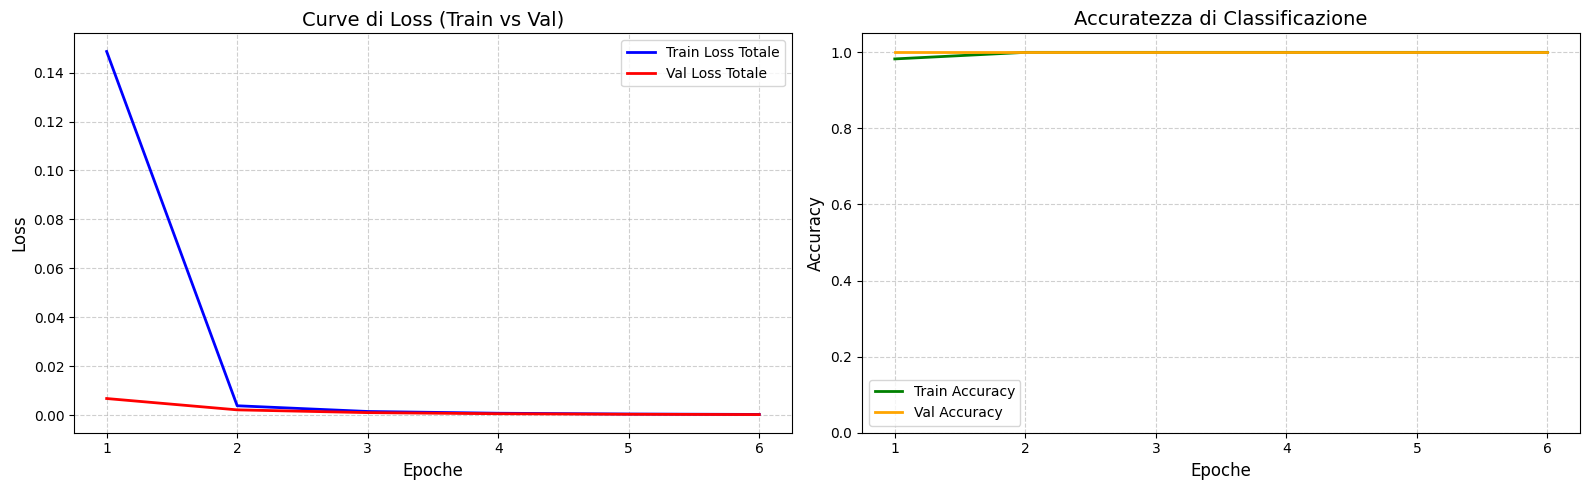

In [13]:
from src.utils.plot import plot_history
plot_history(cp_history)

#### Oracle Test

In [14]:
accuracy, preds, labels, _, _, _ = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=bipolar,
     oracle=True,
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


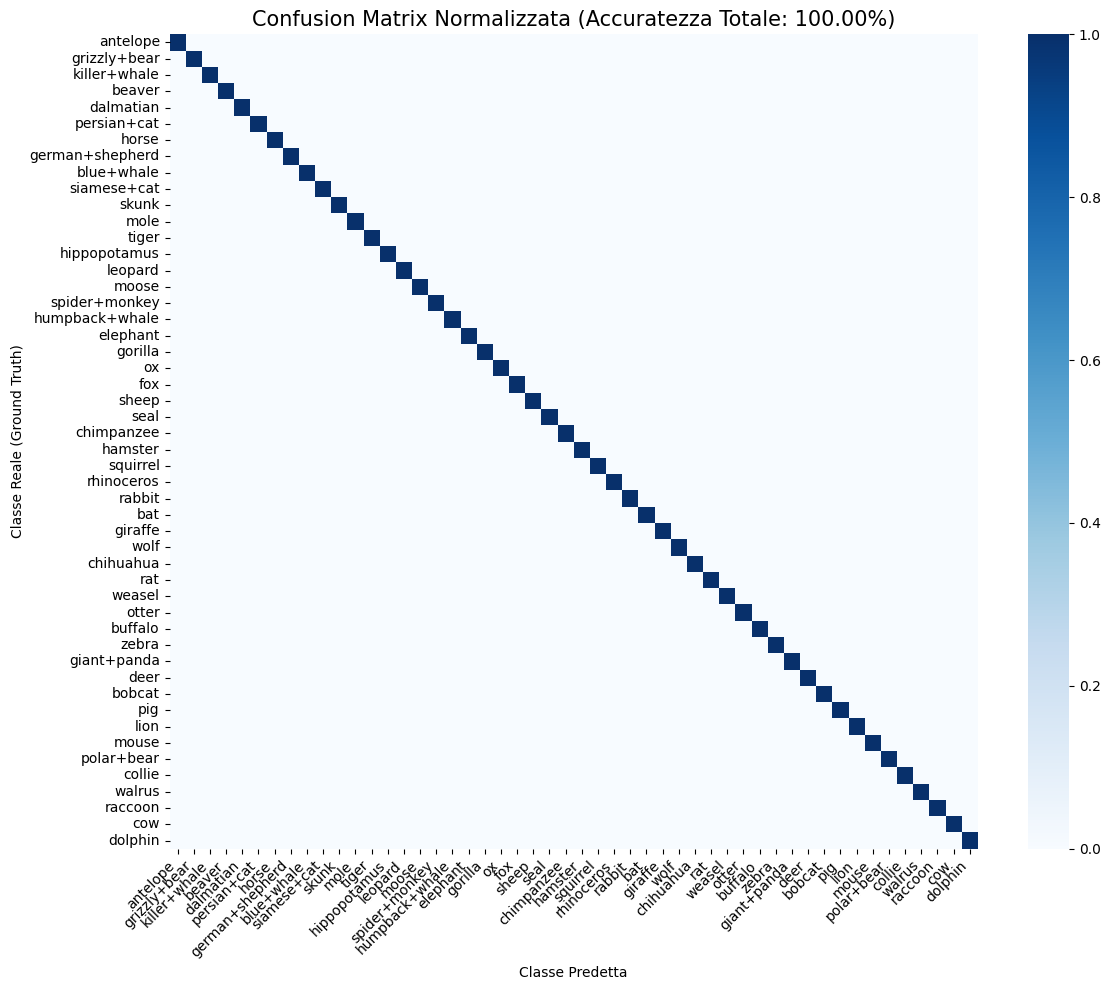


Analisi degli Errori Principali:


In [15]:
plot_test_results(accuracy, preds, labels, class_names=classes)

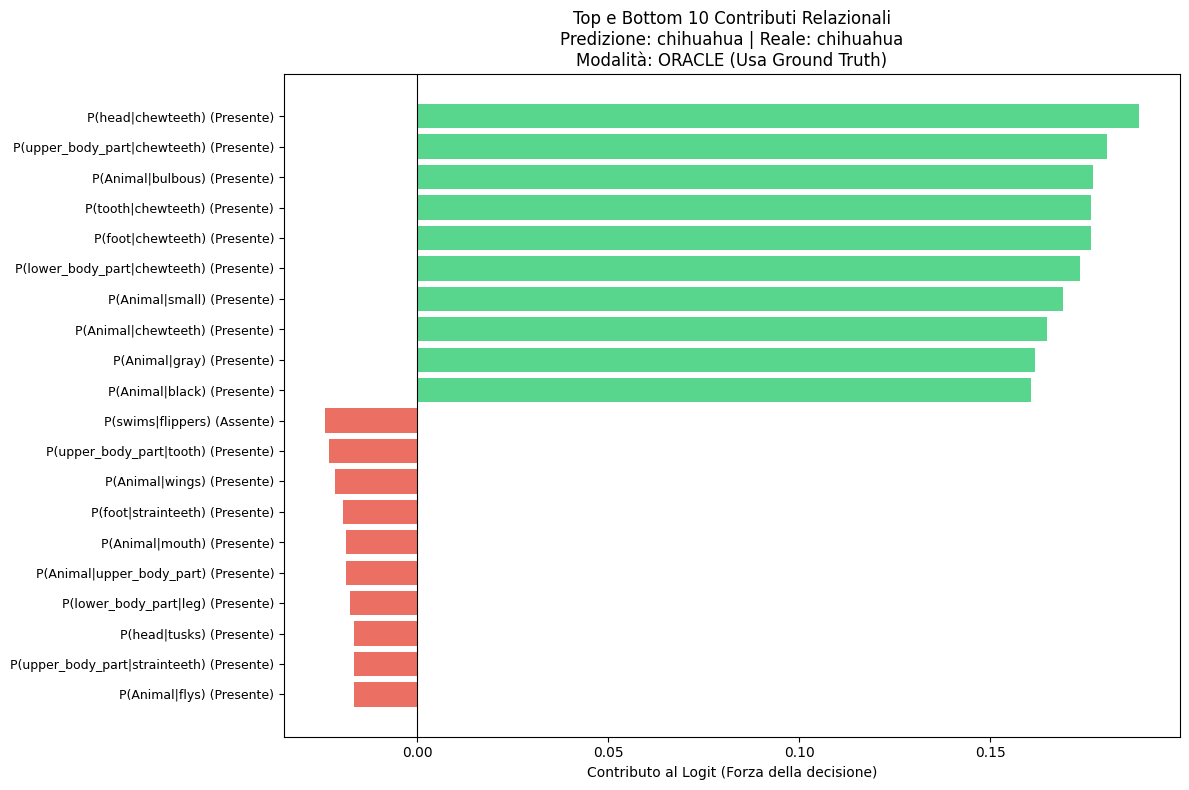

True

In [16]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class="chihuahua", 
    bipolar=bipolar
)

### CBM standard

In [17]:
info = "concepts"
c_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(c_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
c_history = train_cbm_classifier(
    c_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/6 | TRAIN: Loss=1.615, Acc=81.5% | VAL: Loss=0.525, Acc=98.1%
Epoca   3/6 | TRAIN: Loss=0.296, Acc=99.2% | VAL: Loss=0.164, Acc=100.0%
Epoca   4/6 | TRAIN: Loss=0.112, Acc=100.0% | VAL: Loss=0.076, Acc=100.0%
Epoca   5/6 | TRAIN: Loss=0.057, Acc=100.0% | VAL: Loss=0.042, Acc=100.0%
Epoca   6/6 | TRAIN: Loss=0.033, Acc=100.0% | VAL: Loss=0.025, Acc=100.0%
Epoca   7/6 | TRAIN: Loss=0.020, Acc=100.0% | VAL: Loss=0.016, Acc=100.0%
Addestramento completato.


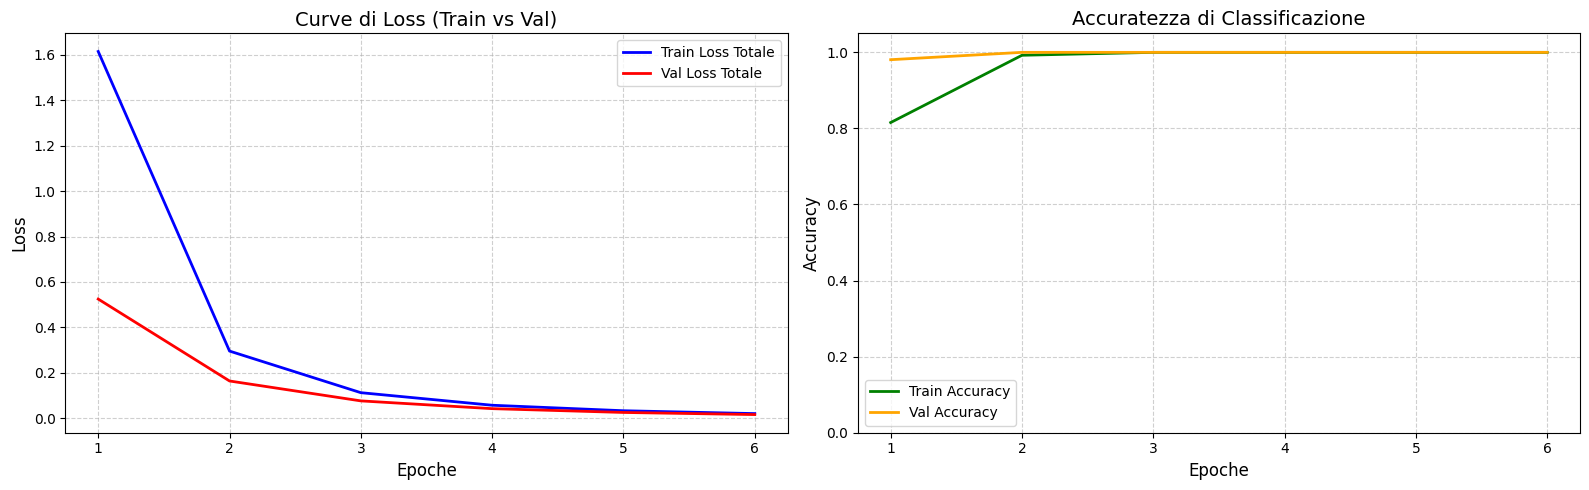

In [18]:
from src.utils.plot import plot_history
plot_history(c_history)

#### Oracle Test

In [19]:
accuracy, preds, labels, _, _, _ = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     oracle=True,
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


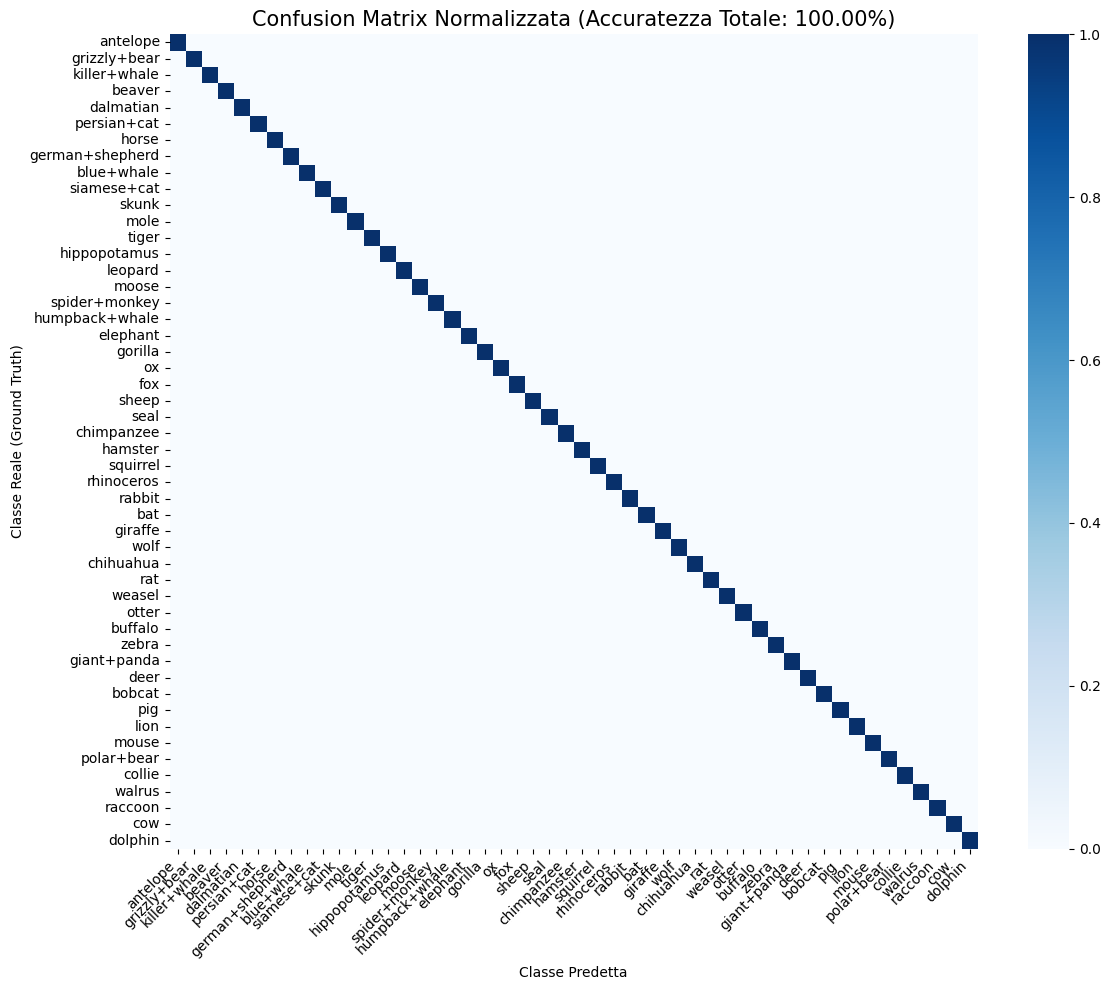


Analisi degli Errori Principali:


In [20]:
plot_test_results(accuracy, preds, labels, class_names=classes)

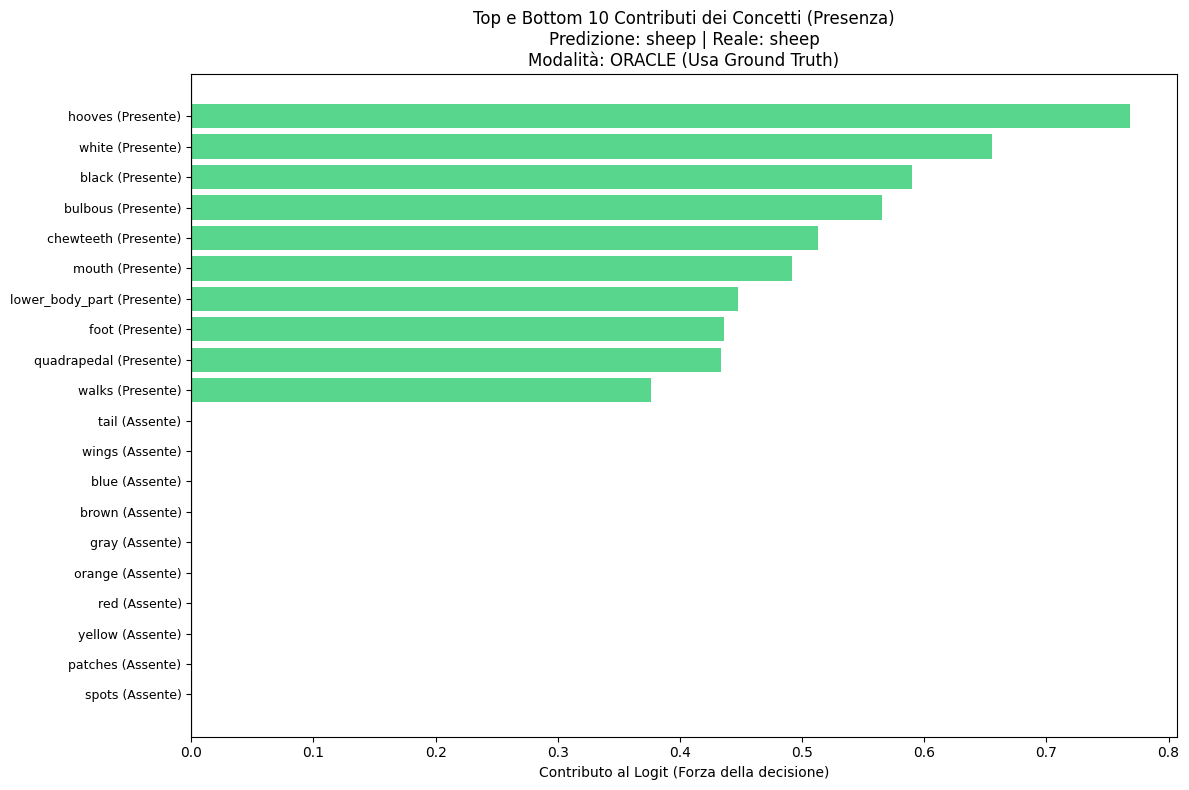

True

In [21]:
from src.CHM.interpretation import explain_prediction

explain_prediction(c_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

## CBM GEOMETRIC CLASSIFIER

In [22]:
BOX_DIM = 16

info = 'dynamic_box'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

box_model = BoxHierarchyModelJoint(num_concepts=len(concepts), num_classes=len(classes), dim=BOX_DIM)
box_model.load_state_dict(torch.load("../../AwA2_Dataset_Labels/Animals_with_Attributes2/modello_gerarchia_joint.pth"))
W_geom = get_geometric_class_weights(box_model, len(classes), len(concepts), device)

In [23]:

concept_weights = box_model.concept_embeddings.weight
class_weights = box_model.class_embeddings.weight
info = 'dynamic_box'
db_model = ConceptBottleneckClassifier(
        num_concepts=len(concepts), 
        box_dim=BOX_DIM, 
        num_classes=len(classes), 
        info=info, 
        concept_embeddings=concept_weights,
        class_embeddings=class_weights
)
info = 'geometric'
g_model = ConceptBottleneckClassifier(
        num_concepts=len(concepts), 
        num_classes=len(classes), 
        box_dim=BOX_DIM, 
        info=info, 
        geometric_weights=W_geom
)

## CONCEPT PREDICTOR

In [24]:
from src.CP.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [25]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    val_dataloader, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

Loss: 3.5220 | Acc: 95.9920 || Val Loss: 2.5406 | Val Acc: 97.0592
Loss: 2.2396 | Acc: 97.4415 || Val Loss: 2.2959 | Val Acc: 97.3287
Loss: 1.9469 | Acc: 97.7514 || Val Loss: 2.2149 | Val Acc: 97.4299
Loss: 1.7805 | Acc: 97.9371 || Val Loss: 2.2446 | Val Acc: 97.3892
Loss: 1.6594 | Acc: 98.0791 || Val Loss: 2.1392 | Val Acc: 97.5237
Loss: 1.5663 | Acc: 98.1876 || Val Loss: 2.1252 | Val Acc: 97.5135


## INDEPENDENT TESTING

### BOXES LINEAR CLASSIFIER

In [26]:
info = "boxes"
box_tensors = prepara_tensore_box(box_dict, concept2id)
b_accuracy, b_preds, b_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 90.15%


#### STATS 

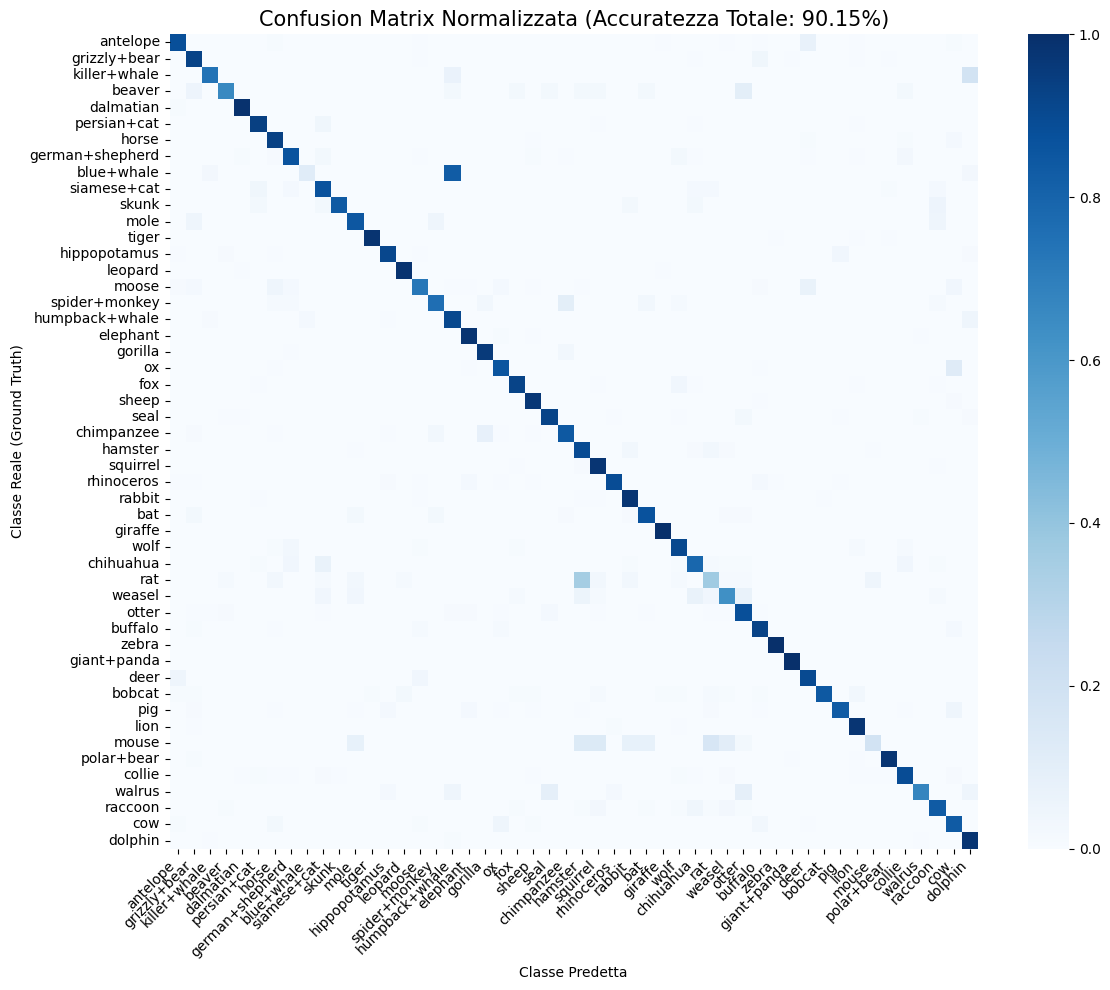


Analisi degli Errori Principali:
 - 29 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 22 volte: 'rat' è stato scambiato per 'hamster'
 - 18 volte: 'ox' è stato scambiato per 'cow'
 - 16 volte: 'antelope' è stato scambiato per 'deer'
 - 12 volte: 'cow' è stato scambiato per 'ox'


In [27]:
plot_test_results(b_accuracy, b_preds, b_labels, class_names=classes)

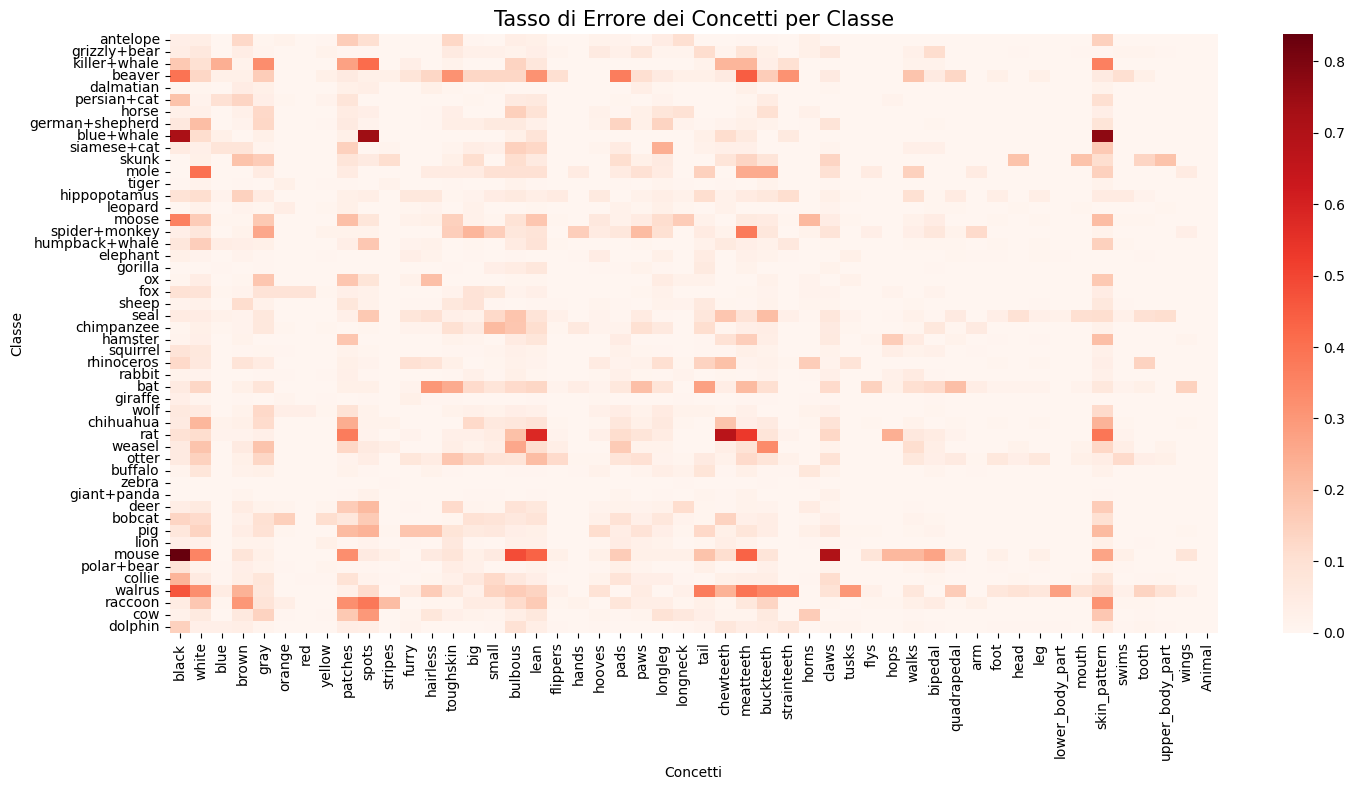

In [28]:
plot_concept_error_heatmap(labels,b_concepts_preds, b_concepts_truth, classes, concepts)

In [29]:
analyze_misclassifications_concepts(b_preds, b_labels, b_concepts_preds, b_concepts_truth, classes, concepts, num_examples=10)


--- ANALISI DEI CONCETTI SUGLI ERRORI (Mostrando 10 esempi) ---

[Esempio Errato #1 - Indice Batch: 3]
Classe Reale: 'collie' ---> Classe Predetta: 'polar+bear'
Concetti Sbagliati (Falsi Positivi / Falsi Negativi):
  - [brown] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [patches] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [small] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [bulbous] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [lean] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [pads] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [claws] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [skin_pattern] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.

[Esempio Errato #2 - Indice Batch: 7]
Classe Reale: 'walrus' ---> Classe Predetta: 'otter'
Concetti Sbagliati (Falsi Positivi / Falsi Negativi):
  - [black] Falso Positivo: D

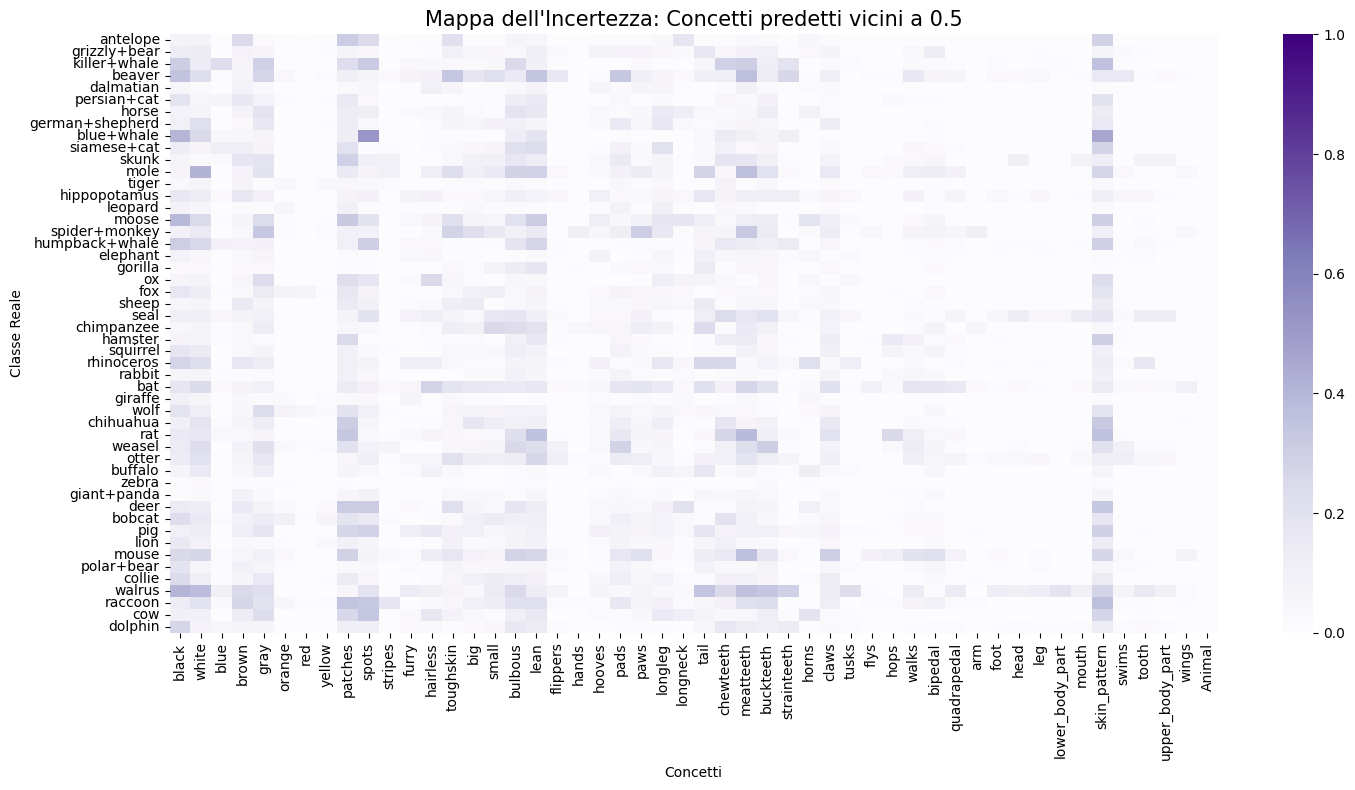

array([[7.63332844e-02, 7.59851336e-02, 2.88073818e-04, ...,
        1.75768109e-05, 7.13520101e-04, 4.04741195e-06],
       [1.36709243e-01, 1.37371674e-01, 2.08473322e-03, ...,
        4.42232052e-03, 8.52084137e-04, 8.63916739e-07],
       [3.04715425e-01, 1.38247371e-01, 2.28541762e-01, ...,
        2.73672258e-03, 1.67615246e-03, 4.91635546e-06],
       ...,
       [1.36619434e-01, 2.04405978e-01, 2.94231568e-02, ...,
        4.16425848e-03, 1.52053935e-02, 1.92371067e-06],
       [9.49327350e-02, 1.02053955e-01, 8.85349407e-04, ...,
        1.59825402e-04, 1.08142398e-04, 2.02477872e-06],
       [2.66680956e-01, 7.94730783e-02, 5.51996380e-02, ...,
        1.80428885e-02, 2.75845150e-03, 2.95815653e-06]])

In [30]:
plot_concept_uncertainty_heatmap(labels, b_concepts_probs, class_names=classes, concept_names=concepts)

#### TEST TIME INTERVENTION


--- Valutazione con k=0 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.15%
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.15%
Inizio valutazione sul Test Set...

Accuratezza Totale: 88.00%
Inizio valutazione sul Test Set...

Accuratezza Totale: 88.00%

--- Valutazione con k=1 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.46%
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.79%
Inizio valutazione sul Test Set...

Accuratezza Totale: 88.41%
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.22%

--- Valutazione con k=2 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.82%
Inizio valutazione sul Test Set...

Accuratezza Totale: 93.44%
Inizio valutazione sul Test Set...

Accuratezza Totale: 88.61%
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.79%

--- Valutazione con k=3 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.21%
Inizio valutazione su

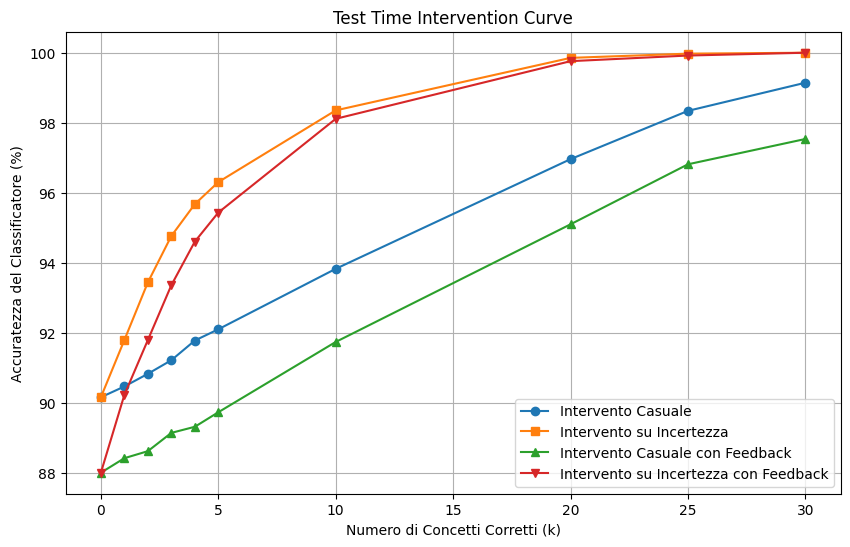

In [31]:
from src.utils.plot import plot_intervention_curve
plot_intervention_curve(
    k_values=[0,1,2,3,4,5,10,20,25,30],
    model=b_model,
    test_loader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    device=device,
    info=info,
    concept_predictor=concept_predictor
)

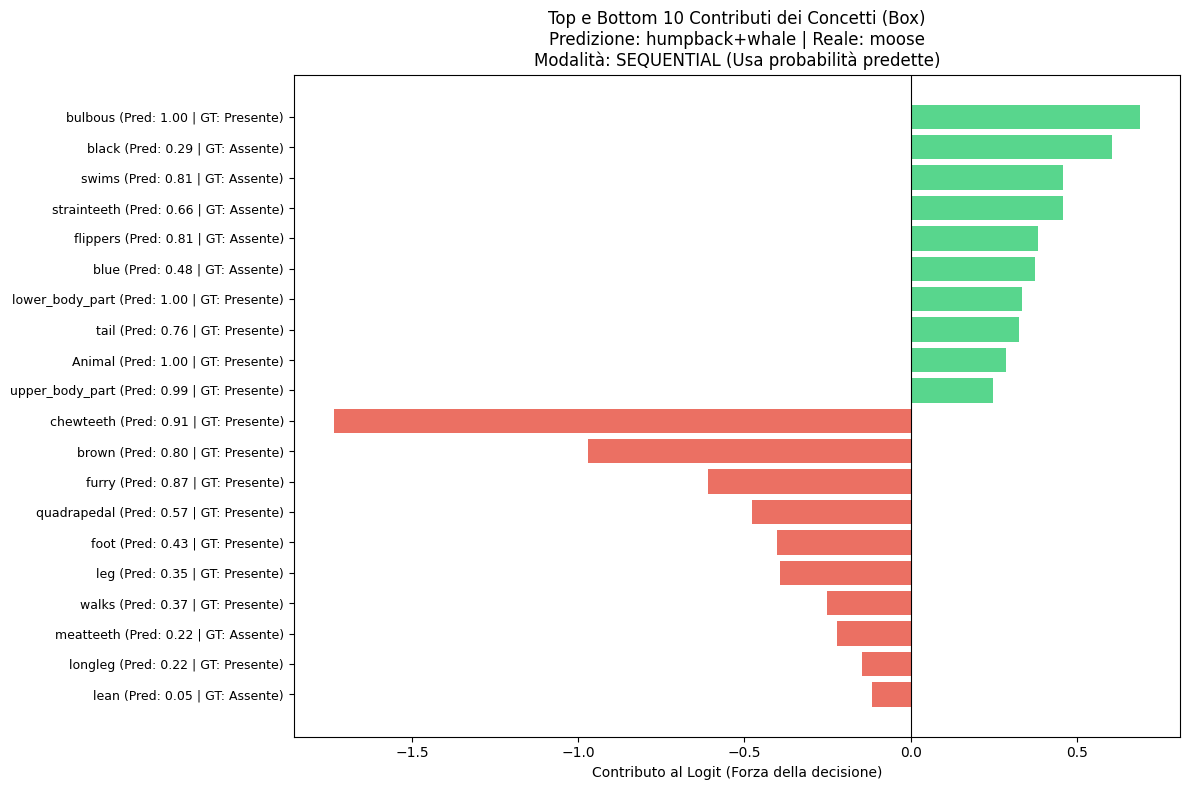

False

In [32]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    b_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class='moose',
    concept_predictor=concept_predictor
    )

### RELATION MATRIX LINEAR CLASSIFIER

In [33]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth, cp_concepts_probs = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 75.26%


In [34]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth, cp_concepts_probs = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=True,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=False
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 89.65%


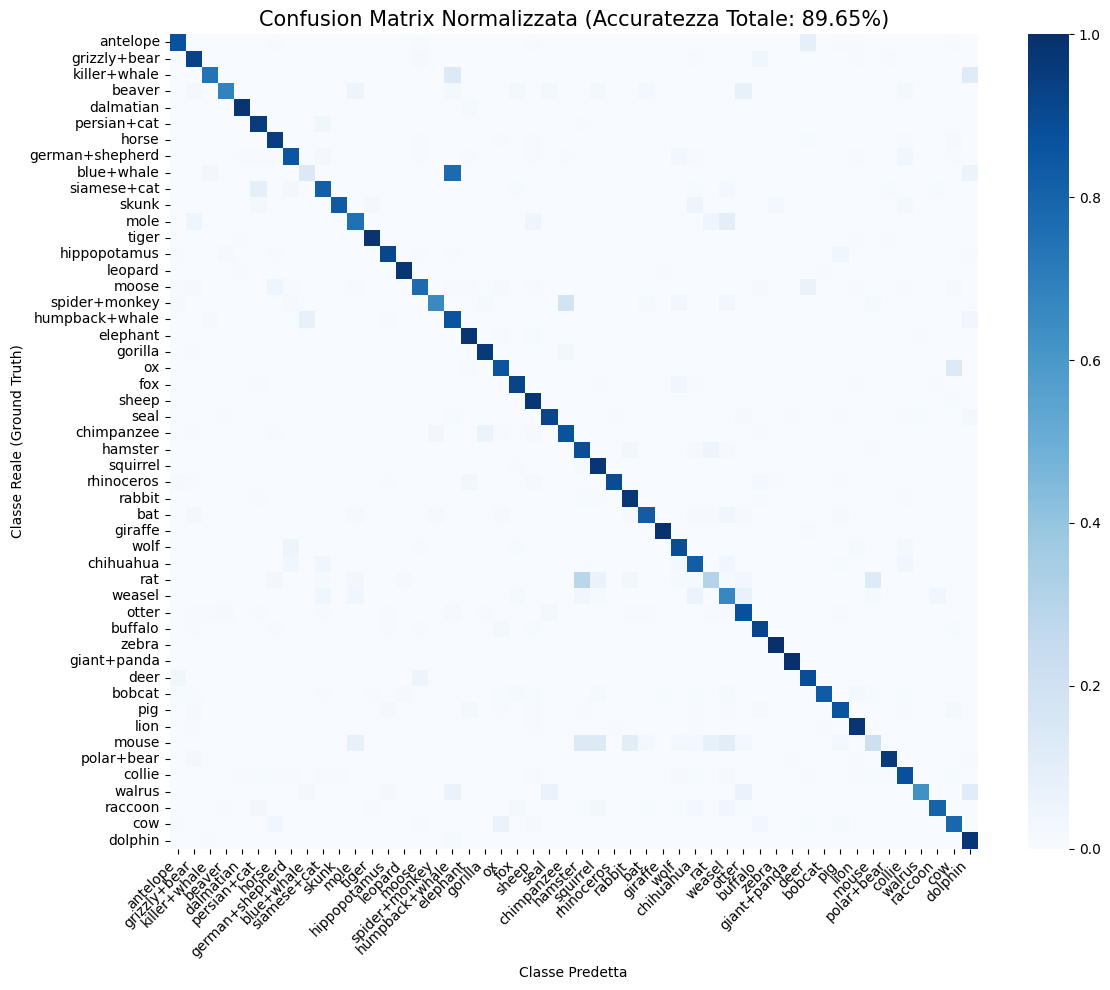


Analisi degli Errori Principali:
 - 27 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 20 volte: 'ox' è stato scambiato per 'cow'
 - 20 volte: 'antelope' è stato scambiato per 'deer'
 - 18 volte: 'rat' è stato scambiato per 'hamster'
 - 17 volte: 'cow' è stato scambiato per 'ox'


In [35]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

### STANDARD CBM LINEAR CLASSIFIER

In [36]:
info = "concepts"
c_accuracy, c_preds, c_labels, c_concepts_preds, c_concepts_truth, c_concepts_probs = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 90.06%


In [37]:
info = "concepts"
c_accuracy, c_preds, c_labels, c_concepts_preds, c_concepts_truth, c_concepts_probs = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=True
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 87.41%


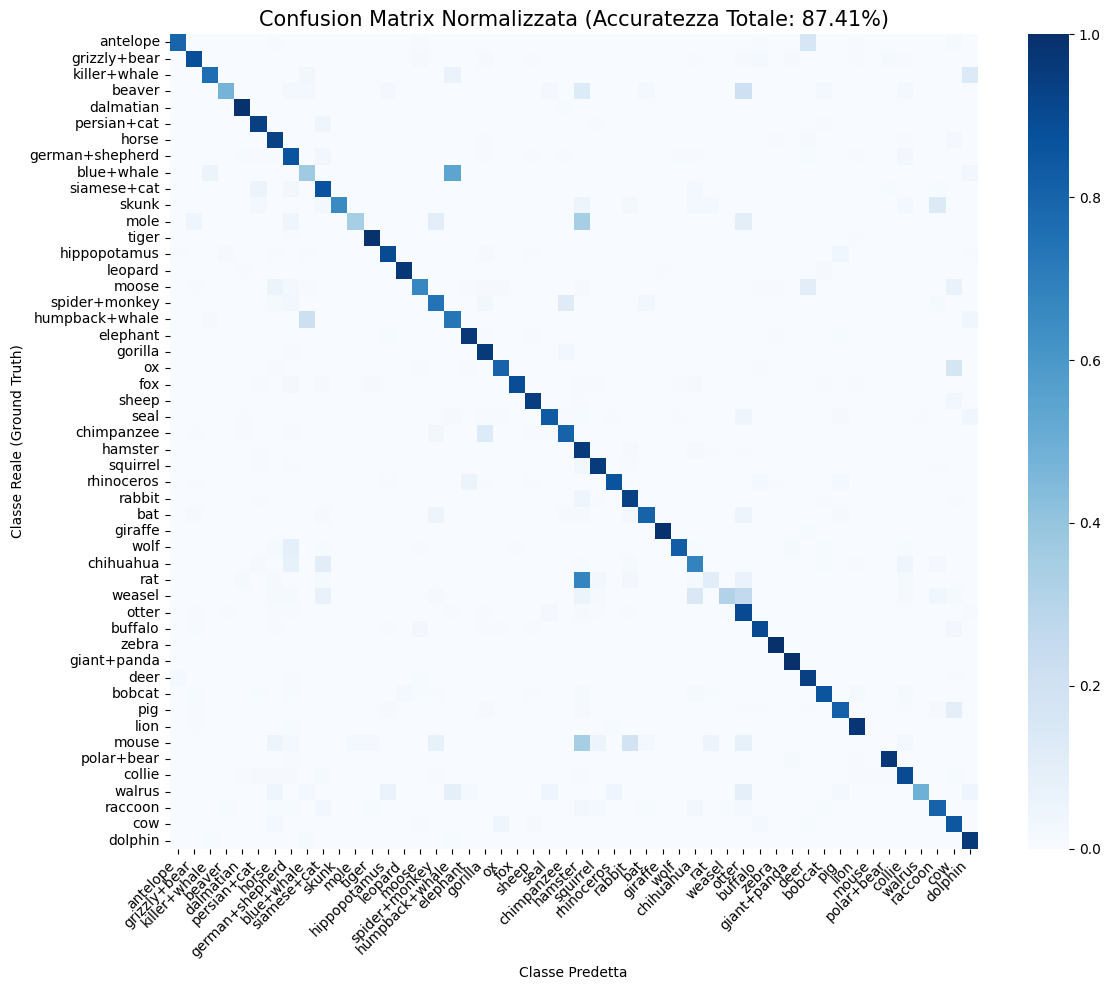


Analisi degli Errori Principali:
 - 42 volte: 'rat' è stato scambiato per 'hamster'
 - 35 volte: 'antelope' è stato scambiato per 'deer'
 - 30 volte: 'humpback+whale' è stato scambiato per 'blue+whale'
 - 25 volte: 'ox' è stato scambiato per 'cow'
 - 19 volte: 'blue+whale' è stato scambiato per 'humpback+whale'


In [38]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

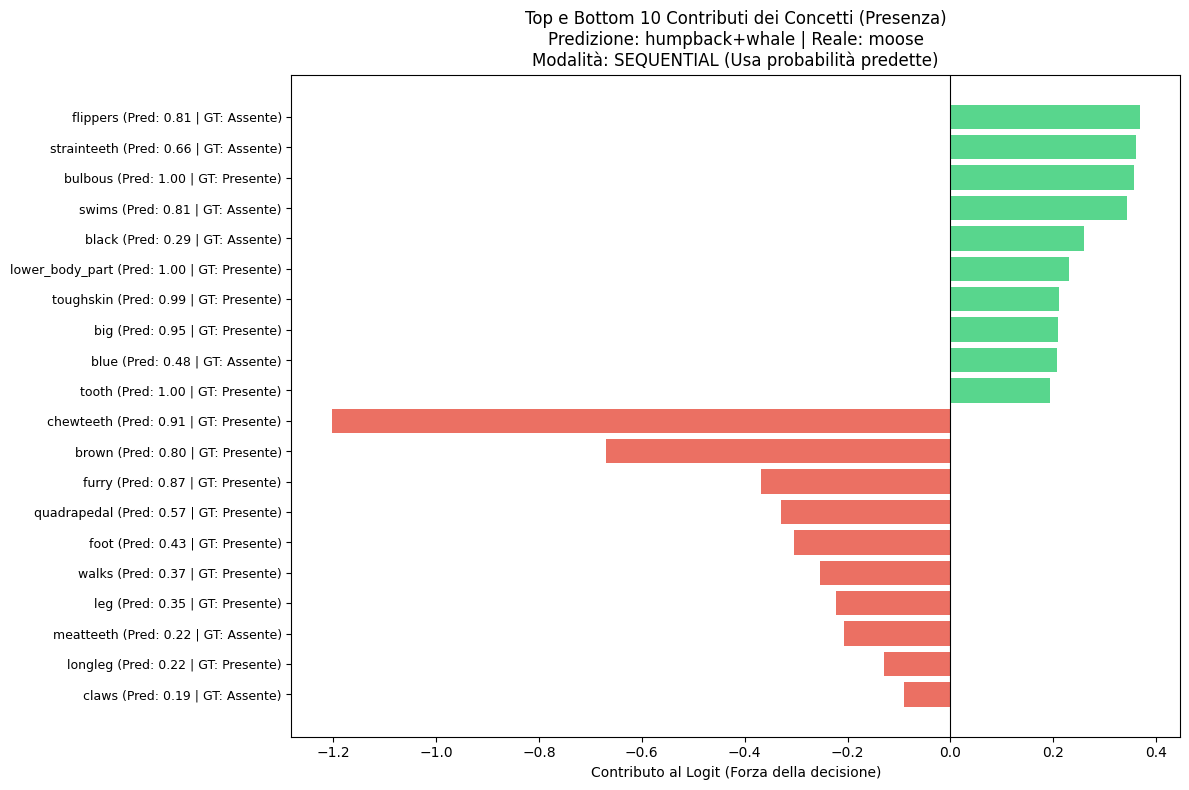

False

In [49]:
from src.CHM.interpretation import explain_prediction
info = 'concepts'
explain_prediction(
    c_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class='moose',
    concept_predictor=concept_predictor
    )

### GEOMETRIC CLASSIFIER

### Oracle Test

In [39]:
box_tensors = None
info = "geometric"
g_accuracy, g_preds, g_labels, _, _, _ = test_cbm_classifier(
     model=g_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 88.12%


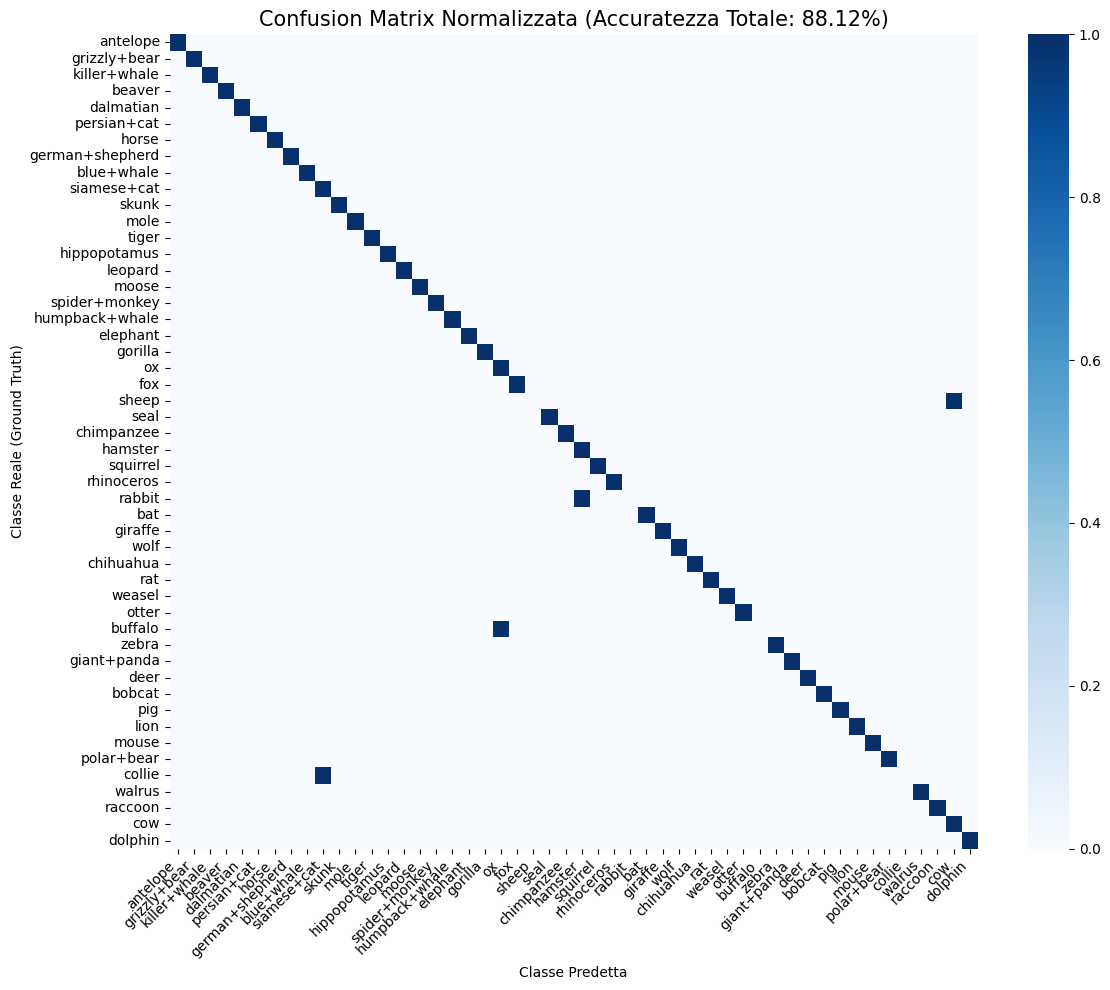


Analisi degli Errori Principali:
 - 284 volte: 'sheep' è stato scambiato per 'cow'
 - 218 volte: 'rabbit' è stato scambiato per 'hamster'
 - 206 volte: 'collie' è stato scambiato per 'siamese+cat'
 - 179 volte: 'buffalo' è stato scambiato per 'ox'


In [40]:
plot_test_results(g_accuracy, g_preds, g_labels, class_names=classes)

### Independent Test

In [41]:
g_accuracy, g_preds, g_labels, g_concepts_preds, g_concepts_truth, g_concepts_probs = test_cbm_classifier(
     model=g_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 72.43%


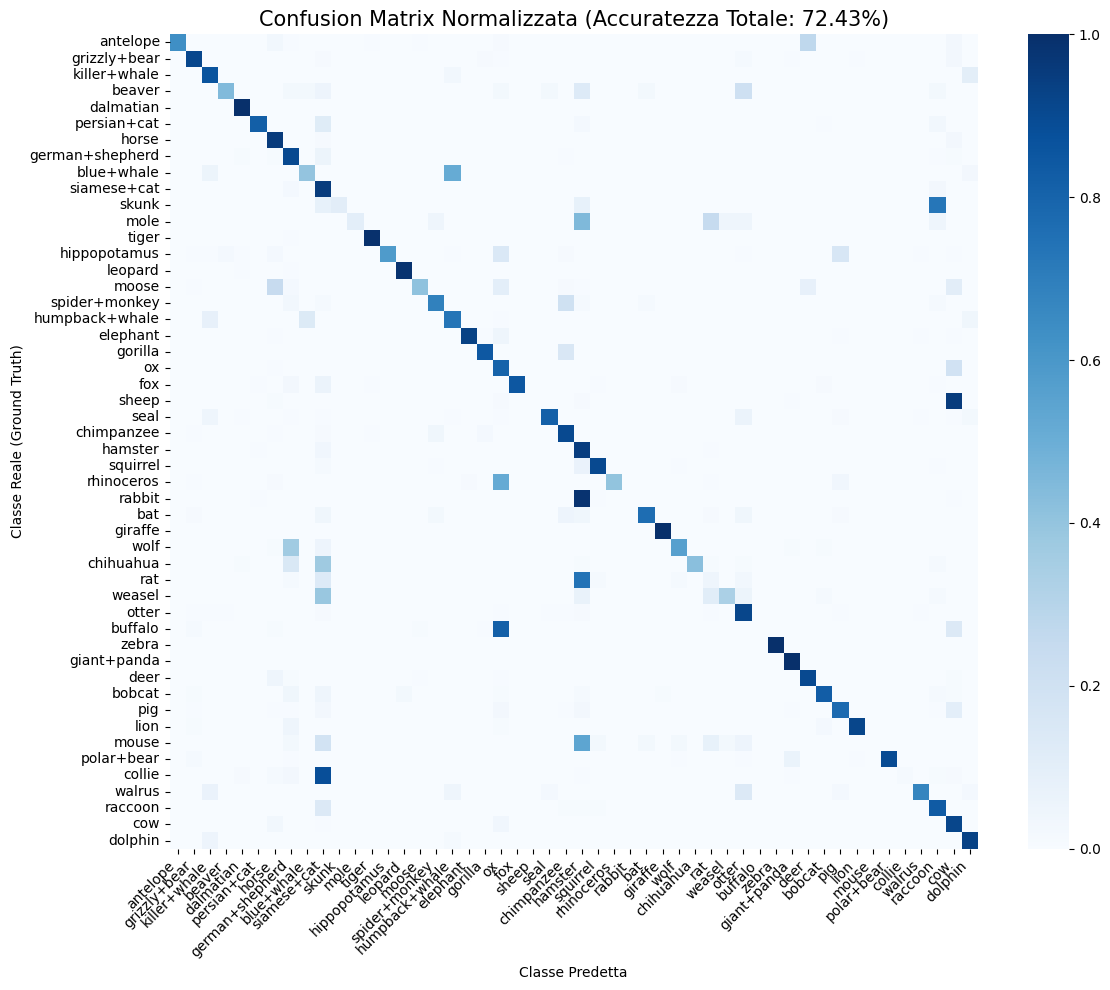


Analisi degli Errori Principali:
 - 270 volte: 'sheep' è stato scambiato per 'cow'
 - 215 volte: 'rabbit' è stato scambiato per 'hamster'
 - 182 volte: 'collie' è stato scambiato per 'siamese+cat'
 - 146 volte: 'buffalo' è stato scambiato per 'ox'
 - 72 volte: 'rhinoceros' è stato scambiato per 'ox'


In [42]:
plot_test_results(g_accuracy, g_preds, g_labels, class_names=classes)

### DYNAMIC BOX CLASSIFIER

### Oracle Test

In [43]:
box_tensors = None
info = "dynamic_box"
db_accuracy, db_preds, db_labels, _, _, _ = test_cbm_classifier(
     model=db_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 74.39%


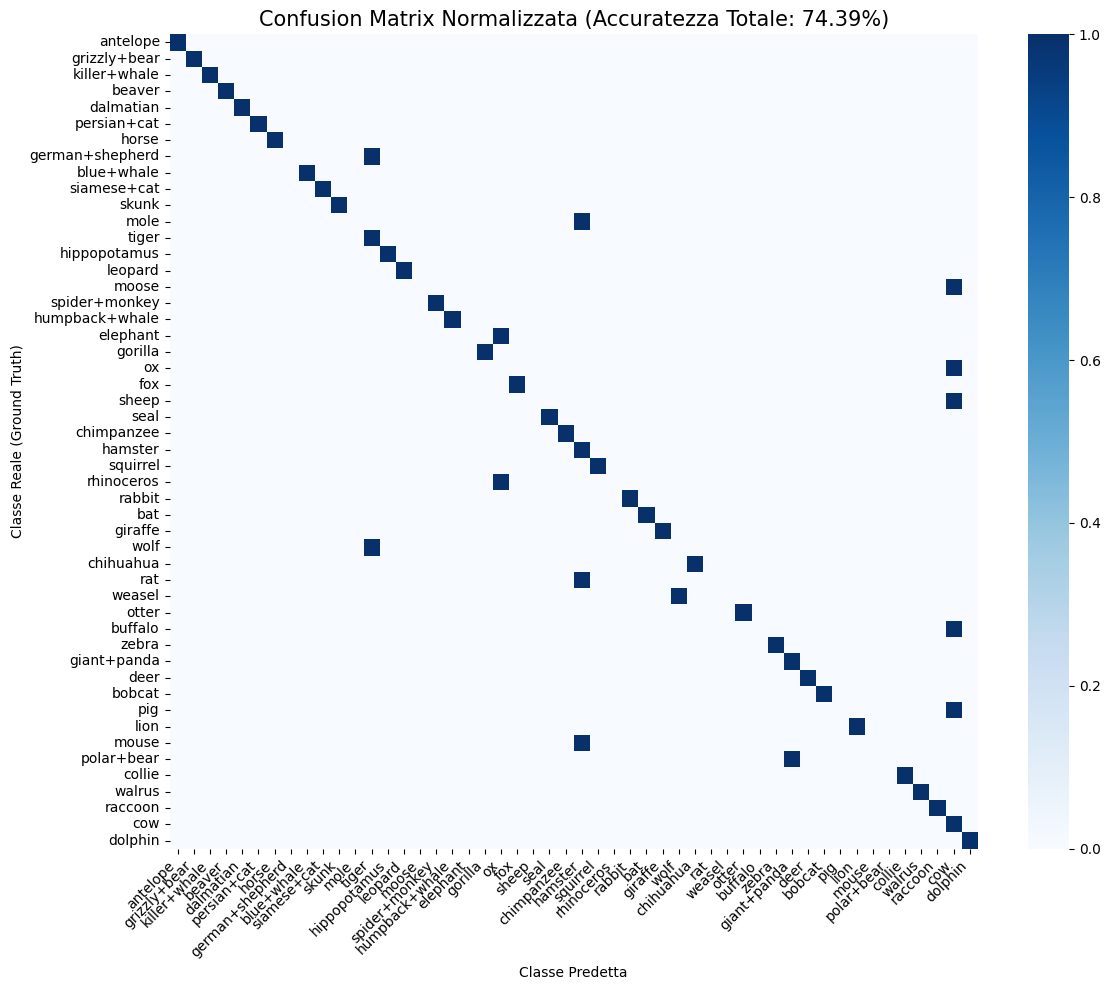


Analisi degli Errori Principali:
 - 284 volte: 'sheep' è stato scambiato per 'cow'
 - 208 volte: 'elephant' è stato scambiato per 'ox'
 - 207 volte: 'german+shepherd' è stato scambiato per 'tiger'
 - 179 volte: 'buffalo' è stato scambiato per 'cow'
 - 174 volte: 'polar+bear' è stato scambiato per 'giant+panda'


In [44]:
plot_test_results(db_accuracy, db_preds, db_labels, class_names=classes)

### Independent Test

In [45]:
db_accuracy, db_preds, db_labels, db_concepts_preds, db_concepts_truth, db_concepts_probs = test_cbm_classifier(
     model=db_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 55.06%


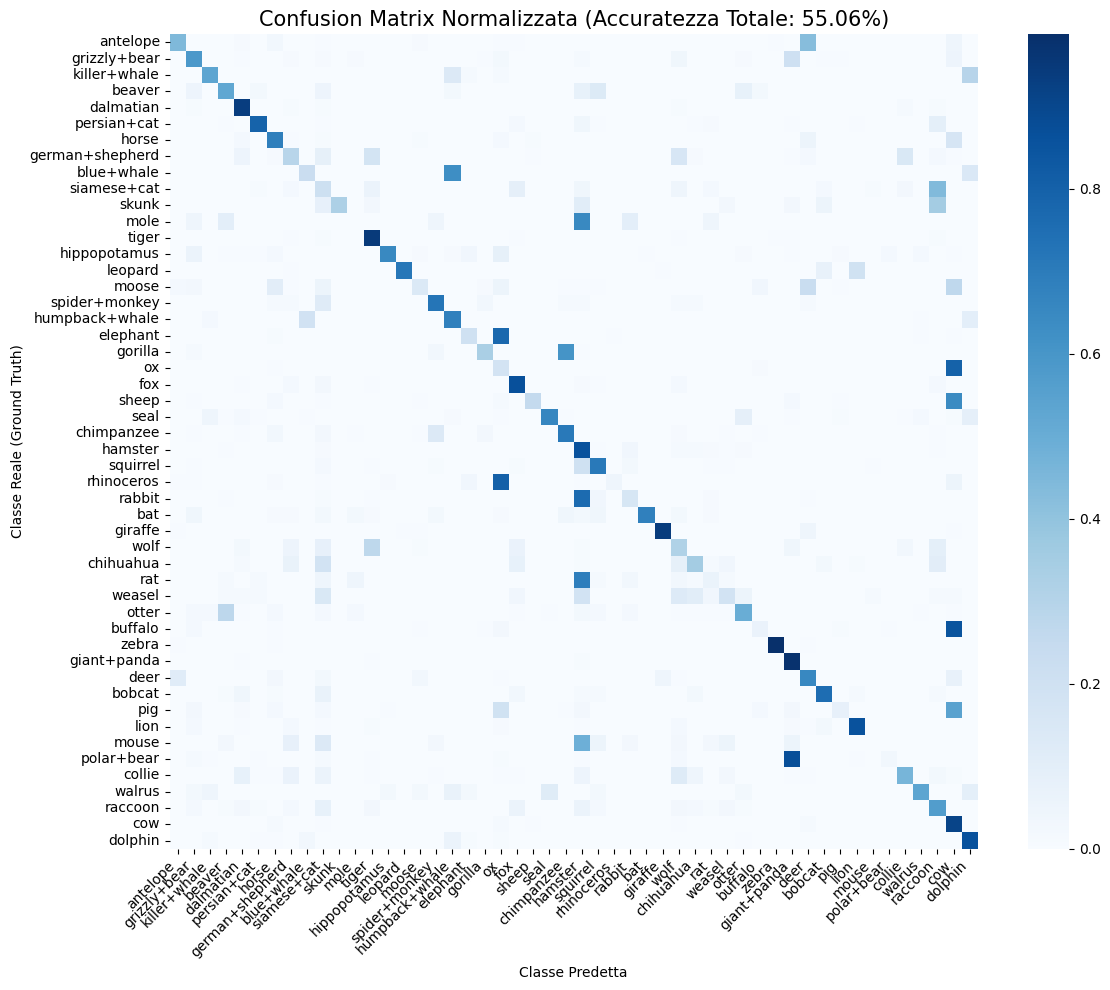


Analisi degli Errori Principali:
 - 182 volte: 'sheep' è stato scambiato per 'cow'
 - 166 volte: 'rabbit' è stato scambiato per 'hamster'
 - 161 volte: 'elephant' è stato scambiato per 'ox'
 - 152 volte: 'buffalo' è stato scambiato per 'cow'
 - 151 volte: 'polar+bear' è stato scambiato per 'giant+panda'


In [46]:
plot_test_results(db_accuracy, db_preds, db_labels, class_names=classes)

Inizio Simulazione TTI...
Concetti Corretti: 0 | Acc Linear: 90.2% | Acc Dynamic Box: 55.1%
Concetti Corretti: 2 | Acc Linear: 93.4% | Acc Dynamic Box: 62.9%
Concetti Corretti: 4 | Acc Linear: 95.7% | Acc Dynamic Box: 67.0%
Concetti Corretti: 6 | Acc Linear: 97.1% | Acc Dynamic Box: 69.4%
Concetti Corretti: 8 | Acc Linear: 97.7% | Acc Dynamic Box: 71.5%
Concetti Corretti: 10 | Acc Linear: 98.4% | Acc Dynamic Box: 72.5%
Concetti Corretti: 12 | Acc Linear: 98.9% | Acc Dynamic Box: 72.9%
Concetti Corretti: 14 | Acc Linear: 99.2% | Acc Dynamic Box: 73.1%
Concetti Corretti: 16 | Acc Linear: 99.5% | Acc Dynamic Box: 73.4%
Concetti Corretti: 18 | Acc Linear: 99.7% | Acc Dynamic Box: 73.7%
Concetti Corretti: 20 | Acc Linear: 99.9% | Acc Dynamic Box: 73.7%


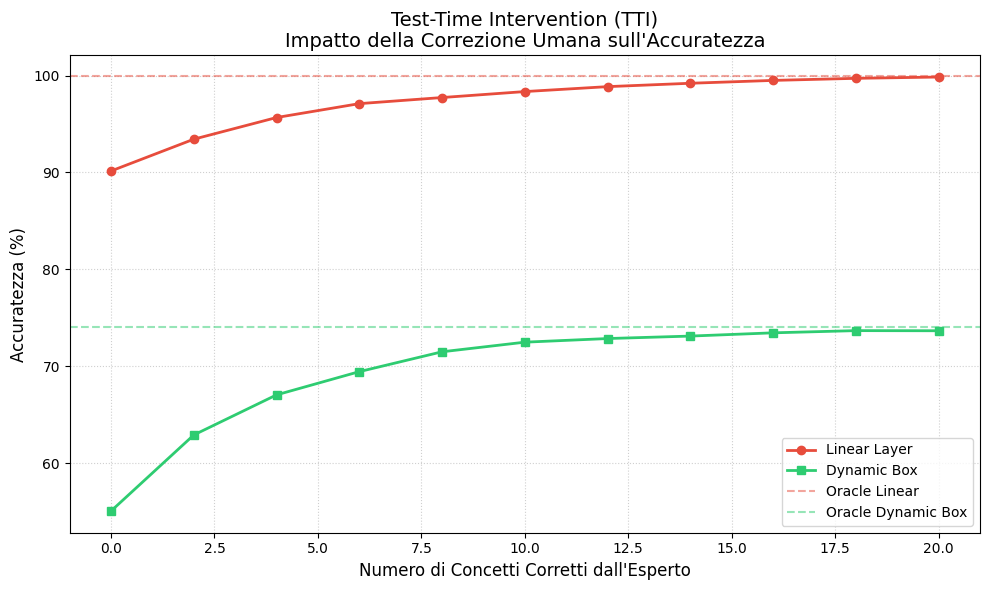

([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
 [90.15405224380441,
  93.43603482920295,
  95.67314132618888,
  97.10649698593437,
  97.73610180843939,
  98.35231078365707,
  98.86135298057603,
  99.20964501004688,
  99.50435365036839,
  99.71868720696584,
  99.85264567983924],
 [55.0569323509712,
  62.90689886135298,
  67.04621567314133,
  69.44407233757535,
  71.49363697253851,
  72.48492967180175,
  72.86001339584729,
  73.11453449430675,
  73.4494306764903,
  73.67716008037507,
  73.66376423308775])

In [ ]:
from src.utils.plot import evaluate_tti_curves

box_tensors = prepara_tensore_box(box_dict, concept2id)
evaluate_tti_curves(
    c_model,
    db_model,
    concept_predictor,
    test_dataloader,
    class_concept_matrix,
    box_tensors,
    device
)